# QSS 20 Final Project — Complete Pipeline

**Author:** Taj Horowitz
**Updated:** May 2026

**Research question:** Does the relationship between state-level socioeconomic conditions and NAEP math scores differ by gender, race, or other demographics? And which dimension of poverty predicts it best?

## Notebook roadmap
1. Imports
2. Load and clean ACS data
3. Pull NAEP scores from the Data Service API
4. Pivot NAEP long → wide and merge onto ACS
5. Inspect merged panel
6. Visualization 1 — state wealth vs. free-lunch score gap
7. Visualization 2 — gender math gap over time

## 1. Imports

In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import re

## 2. Load and clean ACS data

Loads `acs_wmath.csv` (50 states × ~90 ACS columns) and does three things: drops irrelevant columns (math scores (will be using NAEP instead), income-allocation mechanics, granular household subtypes), renames columns to readable short prefixes (`pov_ratio_*`, `educ_*`, `hh_*`), and consolidates educational attainment into 5 standard buckets.

In [43]:
# Data source: QSS 20 course repository
# https://github.com/herbertfreeze/QSS20-S26/tree/main/public_data
df = pd.read_csv("https://raw.githubusercontent.com/herbertfreeze/QSS20-S26/main/public_data/acs_wmath.csv")

# Drop columns that aren't useful for this analysis.
# Math scores come from NAEP instead, so the ACS math columns are redundant.
math_cols = [c for c in df.columns if c.startswith('math_')]

# Income allocation columns describe survey reporting mechanics, not actual income levels.
alloc_cols = [c for c in df.columns if 'allocation_of_household_income' in c]

# The ACS breaks down household composition into very granular subcategories
# (e.g. "biological child", "foster child", "roomer or boarder") that aren't
# meaningful at the state level for this analysis. Keep only the top-level household totals.
hh_drop_keywords = [
    'brother_or_sister', 'adopted_child', 'biological_child', 'stepchild',
    'grandchild', 'parentinlaw', 'soninlaw', 'foster_child',
    'housemate_or_roommate', 'roomer_or_boarder', 'unmarried_partner',
    'other_nonrelatives', 'other_relatives', 'not_living_alone'
]
hh_cols = [c for c in df.columns
           if 'household_type' in c
           and any(kw in c for kw in hh_drop_keywords)]

cols_to_drop = math_cols + alloc_cols + hh_cols
df = df.drop(columns=cols_to_drop)

# Rename columns to something readable.
# The raw ACS column names are long Census-style strings like
# "estimatetotaleducational_attainmentbachelors_degree" — this function
# extracts the meaningful part and prefixes it so columns group nicely.
def clean_acs_col(col):
    if col in ('abbrev', 'FIPS', 'state'):
        return col
    if 'median_household_income' in col:
        return 'median_household_income'
    # For poverty ratio columns, pull out the income bracket from the name
    # using a regex. re.search finds the first match anywhere in the string,
    # and group(1) returns just the captured bracket (e.g. "under 50").
    if 'ratio_of_income_to_poverty' in col:
        match = re.search(r'(under \d+|\d+ to \d+|\d+ and over)', col)
        if match:
            bracket = match.group(1).replace(' to ', '_').replace(' ', '_')
            return f'pov_ratio_{bracket}'
    # For education and household columns, strip everything up to "estimatetotal"
    # (a Census artifact) and clean what remains into a snake_case label.
    if 'educational_attainment' in col:
        level = re.sub(r".*estimatetotal", "", col).strip()
        level = re.sub(r"[^a-zA-Z0-9]", "_", level).strip("_").lower()
        return f'educ_{level}'
    if 'household_type' in col:
        label = re.sub(r".*estimatetotal", "", col).strip()
        label = re.sub(r"[^a-zA-Z0-9]", "_", label).strip("_").lower()
        return f'hh_{label}'
    return col

df.columns = [clean_acs_col(c) for c in df.columns]

# The ACS reports educational attainment at a very fine grain — separate columns
# for every grade level from "no schooling" through "doctorate". That's too
# granular to be useful as predictors, so collapse them into 5 standard buckets
# that match how education is typically categorized in social science research.
less_than_hs_cols = [c for c in df.columns if c.startswith('educ_') and
                     any(x in c for x in ['no_schooling', 'nursery', 'kindergarten',
                                           '1st', '2nd', '3rd', '4th', '5th',
                                           '6th', '7th', '8th', '9th', '10th',
                                           '11th', '12th_grade_no_diploma'])]
hs_cols = [c for c in df.columns if c.startswith('educ_') and
                  any(x in c for x in ['regular_high_school', 'ged'])]
some_col_cols = [c for c in df.columns if c.startswith('educ_') and
                  any(x in c for x in ['some_college', "associate"])]
bachelors_cols = [c for c in df.columns if c.startswith('educ_') and "bachelor" in c]
grad_cols = [c for c in df.columns if c.startswith('educ_') and
                  any(x in c for x in ["master", "professional", "doctorate"])]

df['educ_less_than_hs'] = df[less_than_hs_cols].sum(axis=1)
df['educ_hs_or_ged']    = df[hs_cols].sum(axis=1)
df['educ_some_college'] = df[some_col_cols].sum(axis=1)
df['educ_bachelors']    = df[bachelors_cols].sum(axis=1)
df['educ_graduate']     = df[grad_cols].sum(axis=1)

individual_educ_cols = less_than_hs_cols + hs_cols + some_col_cols + bachelors_cols + grad_cols
df = df.drop(columns=individual_educ_cols)

print(f"\nFinal ACS shape: {df.shape[0]} states x {df.shape[1]} columns")
df.head()


Final ACS shape: 50 states x 54 columns


,abbrev,FIPS,hh_in_group_quarters,hh_in_households,hh_in_householdsin_family_households,hh_in_householdsin_family_householdsbrother_or_sister,hh_in_householdsin_family_householdschild,hh_in_householdsin_family_householdschildadopted_child,hh_in_householdsin_family_householdschildbiological_child,hh_in_householdsin_family_householdshouseholder,hh_in_householdsin_family_householdshouseholderfemale,hh_in_householdsin_family_householdshouseholdermale,hh_in_householdsin_family_householdsnonrelatives,hh_in_householdsin_family_householdsnonrelativesfoster_child,hh_in_householdsin_family_householdsnonrelativeshousemate_or_roommate,hh_in_householdsin_family_householdsnonrelativesother_nonrelatives,hh_in_householdsin_family_householdsnonrelativesroomer_or_boarder,hh_in_householdsin_family_householdsnonrelativesunmarried_partner,hh_in_householdsin_family_householdsother_relatives,hh_in_householdsin_family_householdsparent,hh_in_householdsin_family_householdsspouse,hh_in_householdsin_nonfamily_households,hh_in_householdsin_nonfamily_householdshouseholder,hh_in_householdsin_nonfamily_householdshouseholderfemale,hh_in_householdsin_nonfamily_householdshouseholderfemaleliving_alone,hh_in_householdsin_nonfamily_householdshouseholderfemalenot_living_alone,hh_in_householdsin_nonfamily_householdshouseholdermale,hh_in_householdsin_nonfamily_householdshouseholdermaleliving_alone,hh_in_householdsin_nonfamily_householdshouseholdermalenot_living_alone,hh_in_householdsin_nonfamily_householdsnonrelatives,hh_in_householdsin_nonfamily_householdsnonrelativesfoster_child,hh_in_householdsin_nonfamily_householdsnonrelativeshousemate_or_roommate,hh_in_householdsin_nonfamily_householdsnonrelativesother_nonrelatives,hh_in_householdsin_nonfamily_householdsnonrelativesroomer_or_boarder,hh_in_householdsin_nonfamily_householdsnonrelativesunmarried_partner,median_household_income,pov_ratio_100_124,pov_ratio_125_149,pov_ratio_150_174,pov_ratio_175_184,pov_ratio_185_199,pov_ratio_200_299,pov_ratio_300_399,pov_ratio_400_499,pov_ratio_50_74,pov_ratio_500_and_over,pov_ratio_75_99,pov_ratio_under_50,state,educ_less_than_hs,educ_hs_or_ged,educ_some_college,educ_bachelors,educ_graduate
0,AK,2,0.036734,0.963266,0.810929,0.010862,0.310748,0.013247,0.281835,0.235129,0.109859,0.125270,0.030205,0.001259,0.004554,0.009375,0.001906,0.013111,0.013608,0.007140,0.175362,0.152337,0.114577,0.050762,0.040121,0.010641,0.063815,0.048792,0.015023,0.037760,0.000121,0.014351,0.006246,0.002561,0.014481,70760.0,0.027455,0.030921,0.034044,0.012854,0.021752,0.133592,0.139195,0.126654,0.018044,0.405049,0.023440,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924
1,AL,1,0.024045,0.975955,0.826924,0.011469,0.295471,0.007387,0.273201,0.258724,0.117551,0.141173,0.015479,0.000741,0.002808,0.004245,0.001162,0.006523,0.015750,0.009388,0.183907,0.149032,0.124393,0.067930,0.061250,0.006680,0.056463,0.047519,0.008944,0.024639,0.000145,0.011140,0.003459,0.002397,0.007497,43253.0,0.046204,0.047627,0.047443,0.019266,0.028022,0.173686,0.142227,0.107536,0.040327,0.244524,0.043376,0.059761,Alabama,0.168852,0.310562,0.294274,0.143547,0.082766
2,AR,5,0.027476,0.972524,0.820648,0.009649,0.286215,0.007786,0.262647,0.260070,0.116855,0.143215,0.018170,0.000783,0.002591,0.005358,0.001392,0.008047,0.014600,0.009192,0.191166,0.151877,0.125058,0.066929,0.059089,0.007839,0.058130,0.047530,0.010600,0.026818,0.000147,0.009638,0.005074,0.001994,0.009965,40768.0,0.049852,0.055226,0.054676,0.021142,0.030210,0.184689,0.144202,0.101924,0.040962,0.213614,0.047099,0.056403,Arkansas,0.162692,0.350798,0.285475,0.132791,0.068245
3,AZ,4,0.022178,0.977822,0.815796,0.013613,0.297599,0.007484,0.277456,0.241233,0.104570,0.136664,0.025024,0.000814,0.004190,0.006916,0.001776,0.011327,0.016388,0.013115,0.175743,0.162027,0.124569,0.063983,0.052711,0.011272,0.060586,0.046518,0.014068,0.037458,0.000120,0.014895,0.005487,0.002945,0.014011,49774.0,0.042628,0.046291,0.044970,0.017010,0.027557,0.170580,0.139722,0.106371,0.035498,0.275244,0.0

## 3. Pull NAEP scores from the Data Service API

Pulls mean math scores for 5 demographic breakdowns across grades 4 & 8 and years 2013–2019.

| Variable | Meaning |
|---|---|
| `SLUNCH3` | Free/reduced-price lunch eligibility |
| `GENDER`  | Male / Female |
| `SRACE10` | Race/ethnicity |
| `PARED`   | Parental education (grade 8 only) |
| `SCHTYPE` | Public vs. private school |

Result: ~7,800 rows in long format (one row per state × grade × year × subgroup category).

In [44]:
SUBSCALE  = 'MRPCM'   # math composite score — the main NAEP math metric
VARIABLES = ['SLUNCH3', 'SRACE10', 'GENDER', 'PARED', 'SCHTYPE']
GRADES    = [4, 8]           # NAEP tests grades 4 and 8 on a consistent schedule; grade 12 data is sparse
YEARS     = [2013, 2015, 2017, 2019]  # administered every other year
STATES    = list(df['abbrev'].unique())

# Passing all states as a comma-separated string lets the API return all 50 at once.
# Without this, the loop would make ~1,800 requests; this way it's around 36.
ALL_STATES_STR = ','.join(STATES)


def pull_naep_all_states(variable, grade, year, states_str, retries=3):
    # The NAEP Data Service API works by building a URL with query parameters —
    # each &key=value is a filter the server applies before returning results.
    # The URL is constructed by string concatenation here because Python's adjacent
    # string literals auto-join, and adding variables mid-string requires the + operator.
    for attempt in range(retries):
        query = (
            'https://www.nationsreportcard.gov/Dataservice/GetAdhocData.aspx?'
            'type=data'
            '&subject=mathematics'
            '&grade=' + str(grade) +
            '&subscale=' + SUBSCALE +
            '&variable=' + variable +
            '&jurisdiction=' + states_str +    # comma-separated state abbreviations
            '&stattype=MN:MN'                  # MN:MN requests mean scores, not percentiles
            '&Year=' + str(year)
        )

        try:
            # requests.get() fires a standard HTTP GET request. timeout=30 prevents
            # the script from hanging indefinitely if the server stops responding.
            r = requests.get(query, timeout=30)

            # The API response is JSON — a text-based format structured like a Python dict.
            # .json() deserializes it into an actual dict so the data can be accessed by key.
            data = r.json()

            # Using .get('result') instead of ['result'] means a missing key returns None
            # rather than raising a KeyError — safer when the API occasionally returns
            # an error response instead of data.
            if data.get('result'):
                return pd.DataFrame(data['result'])

        except Exception as e:
            print(f'  Bulk attempt {attempt+1} failed: {e}')
            # Exponential back-off: sleep 1s on the first retry, 2s on the second, 4s on the third.
            # This avoids immediately re-hammering a server that's already under stress.
            time.sleep(2 ** attempt)

    # If the bulk request failed after all retries, fall back to requesting each state
    # individually. Slower, but isolates any single state causing problems from the rest.
    print(f'  Falling back to per-state for {variable} grade {grade} {year}...')
    results_list = []

    for state in states_str.split(','):
        q = (
            'https://www.nationsreportcard.gov/Dataservice/GetAdhocData.aspx?'
            'type=data'
            '&subject=mathematics'
            '&grade=' + str(grade) +
            '&subscale=' + SUBSCALE +
            '&variable=' + variable +
            '&jurisdiction=' + state +
            '&stattype=MN:MN'
            '&Year=' + str(year)
        )
        try:
            r = requests.get(q, timeout=15)
            data = r.json()
            if data.get('result'):
                results_list.append(pd.DataFrame(data['result']))
        except Exception as e:
            print(f'    Failed: {state} — {e}')

        time.sleep(0.3)  # brief pause to avoid triggering rate limiting

    # ignore_index=True resets row numbers after stacking — without it,
    # each per-state DataFrame would restart its index from 0, creating duplicates.
    if results_list:
        return pd.concat(results_list, ignore_index=True)

    return pd.DataFrame()


# PARED (parental education) is only collected at grade 8. Grade 4 students are
# too young to reliably report their parents' education level, so NAEP doesn't ask.
# Skipping this combination avoids ~200 requests that would return nothing.
GRADE_RESTRICTIONS = {
    'PARED': [8],
}

all_dfs = []

for variable in VARIABLES:
    # dict.get(key, default) returns the default value when the key isn't present,
    # so variables without restrictions automatically get both grades.
    allowed_grades = GRADE_RESTRICTIONS.get(variable, GRADES)

    for grade in allowed_grades:
        for year in YEARS:
            print(f'Pulling {variable}, grade {grade}, {year}...')
            result = pull_naep_all_states(variable, grade, year, ALL_STATES_STR)
            if not result.empty:
                all_dfs.append(result)
            time.sleep(0.5)

naep_raw = pd.concat(all_dfs, ignore_index=True)
print('\nTotal rows pulled:', len(naep_raw))

# The raw API response contains many columns — keep only the ones needed for analysis.
naep_clean = naep_raw[[
    'jurisdiction',    # state abbreviation (e.g. 'NH')
    'jurisLabel',      # full state name (e.g. 'New Hampshire')
    'grade',
    'year',
    'variable',        # demographic breakdown label (e.g. 'GENDER')
    'varValueLabel',   # category within that variable (e.g. 'Male', 'Female')
    'value'            # mean math score
]].copy()

naep_clean.columns = [
    'state_abbrev', 'state_name', 'grade', 'year',
    'variable', 'category', 'mean_score'
]

naep_clean['mean_score'] = naep_clean['mean_score'].round(2)

# NAEP suppresses scores when a subgroup has too few students to report reliably.
# Those show up as NaN after parsing — drop them rather than carry forward missing data.
naep_clean = naep_clean.dropna(subset=['mean_score'])

print('naep_clean shape:', naep_clean.shape)
naep_clean.head(15)

os.makedirs("data", exist_ok=True)
naep_clean.to_csv("data/naep_pulled.csv", index=False)
print("Saved to data/naep_pulled.csv")

Pulling SLUNCH3, grade 4, 2013...
Pulling SLUNCH3, grade 4, 2015...
Pulling SLUNCH3, grade 4, 2017...
Pulling SLUNCH3, grade 4, 2019...
Pulling SLUNCH3, grade 8, 2013...
Pulling SLUNCH3, grade 8, 2015...
Pulling SLUNCH3, grade 8, 2017...
Pulling SLUNCH3, grade 8, 2019...
Pulling SRACE10, grade 4, 2013...
Pulling SRACE10, grade 4, 2015...
Pulling SRACE10, grade 4, 2017...
Pulling SRACE10, grade 4, 2019...
Pulling SRACE10, grade 8, 2013...
Pulling SRACE10, grade 8, 2015...
Pulling SRACE10, grade 8, 2017...
Pulling SRACE10, grade 8, 2019...
Pulling GENDER, grade 4, 2013...
Pulling GENDER, grade 4, 2015...
Pulling GENDER, grade 4, 2017...
Pulling GENDER, grade 4, 2019...
Pulling GENDER, grade 8, 2013...
Pulling GENDER, grade 8, 2015...
Pulling GENDER, grade 8, 2017...
Pulling GENDER, grade 8, 2019...
Pulling PARED, grade 8, 2013...
Pulling PARED, grade 8, 2015...
Pulling PARED, grade 8, 2017...
Pulling PARED, grade 8, 2019...
Pulling SCHTYPE, grade 4, 2013...
Pulling SCHTYPE, grade 4, 2015

## 4. Pivot NAEP wide and merge onto ACS

Pivots NAEP from long to wide (one row per state × grade × year, one column per subgroup score), replaces NAEP's `999` suppression sentinel with `NaN`, then left-merges the ACS onto the NAEP panel. Final shape: 400 rows × 78 columns.

In [45]:
# The NAEP data comes back in "long" format — one row per state per subgroup category.
# For example, NH grade 4 2019 appears as two separate rows: one for Male, one for Female.
# pivot_table() reshapes this so each state/grade/year combination is a single row,
# with separate columns for each subgroup score (gender_male, gender_female, etc.).
naep_wide = naep_clean.pivot_table(
    index=['state_abbrev', 'grade', 'year'],
    columns=['variable', 'category'],
    values='mean_score'
)

# pivot_table() creates a MultiIndex column like ('GENDER', 'Male').
# This flattens those into a single readable string like 'gender_male'.
naep_wide.columns = [
    (var + '_' + cat).lower().replace(' ', '_').replace("'", '').replace('/', '_')
    for var, cat in naep_wide.columns
]

naep_wide = naep_wide.reset_index()

# NAEP uses 999 as a sentinel value for suppressed scores (not actual data).
# Replace with pd.NA so these don't skew any calculations downstream.
naep_wide = naep_wide.replace(999, pd.NA)

print('NAEP wide shape:', naep_wide.shape)

# Merge ACS onto NAEP using a left join, keeping all NAEP rows.
# The ACS snapshot is from 2018, so it's the same for every year of NAEP data —
# this is a known limitation noted in the analysis.
merged = naep_wide.merge(df, left_on='state_abbrev', right_on='abbrev', how='left')
merged = merged.drop(columns=['abbrev'])  # redundant after the merge

print('Merged shape:', merged.shape)
print('Expected: ~400 rows (50 states x 2 grades x 4 years)')

# Sanity check — any state that failed to match will have NaN for income.
unmatched = merged[merged['median_household_income'].isna()]['state_abbrev'].tolist()
print('States with no ACS match:', unmatched)
merged.head(10)

NAEP wide shape: (400, 25)
Merged shape: (400, 78)
Expected: ~400 rows (50 states x 2 grades x 4 years)
States with no ACS match: []


,state_abbrev,grade,year,gender_female,gender_male,pared_did_not_finish_high_school,pared_graduated_college,pared_graduated_high_school,pared_some_education_after_high_school,pared_unknown,schtype_bureau_of_indian_education,schtype_catholic,schtype_department_of_defense,schtype_other_private,schtype_public,slunch3_eligible,slunch3_information_not_available,slunch3_not_eligible,srace10_american_indian_alaska_native,srace10_asian,srace10_black,srace10_hispanic,srace10_native_hawaiian_other_pacific_islander,srace10_two_or_more_races,srace10_white,FIPS,hh_in_group_quarters,hh_in_households,hh_in_householdsin_family_households,hh_in_householdsin_family_householdsbrother_or_sister,hh_in_householdsin_family_householdschild,hh_in_householdsin_family_householdschildadopted_child,hh_in_householdsin_family_householdschildbiological_child,hh_in_householdsin_family_householdshouseholder,hh_in_householdsin_family_householdshouseholderfemale,hh_in_householdsin_family_householdshouseholdermale,hh_in_householdsin_family_householdsnonrelatives,hh_in_householdsin_family_householdsnonrelativesfoster_child,hh_in_householdsin_family_householdsnonrelativeshousemate_or_roommate,hh_in_householdsin_family_householdsnonrelativesother_nonrelatives,hh_in_householdsin_family_householdsnonrelativesroomer_or_boarder,hh_in_householdsin_family_householdsnonrelativesunmarried_partner,hh_in_householdsin_family_householdsother_relatives,hh_in_householdsin_family_householdsparent,hh_in_householdsin_family_householdsspouse,hh_in_householdsin_nonfamily_households,hh_in_householdsin_nonfamily_householdshouseholder,hh_in_householdsin_nonfamily_householdshouseholderfemale,hh_in_householdsin_nonfamily_householdshouseholderfemaleliving_alone,hh_in_householdsin_nonfamily_householdshouseholderfemalenot_living_alone,hh_in_householdsin_nonfamily_householdshouseholdermale,hh_in_householdsin_nonfamily_householdshouseholdermaleliving_alone,hh_in_householdsin_nonfamily_householdshouseholdermalenot_living_alone,hh_in_householdsin_nonfamily_householdsnonrelatives,hh_in_householdsin_nonfamily_householdsnonrelativesfoster_child,hh_in_householdsin_nonfamily_householdsnonrelativeshousemate_or_roommate,hh_in_householdsin_nonfamily_householdsnonrelativesother_nonrelatives,hh_in_householdsin_nonfamily_householdsnonrelativesroomer_or_boarder,hh_in_householdsin_nonfamily_householdsnonrelativesunmarried_partner,median_household_income,pov_ratio_100_124,pov_ratio_125_149,pov_ratio_150_174,pov_ratio_175_184,pov_ratio_185_199,pov_ratio_200_299,pov_ratio_300_399,pov_ratio_400_499,pov_ratio_50_74,pov_ratio_500_and_over,pov_ratio_75_99,pov_ratio_under_50,state,educ_less_than_hs,educ_hs_or_ged,educ_some_college,educ_bachelors,educ_graduate
0,AK,4,2013,235.67,236.55,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,236.12,224.42,<NA>,248.55,212.83,237.15,228.15,234.62,223.38,237.86,249.06,2,0.036734,0.963266,0.810929,0.010862,0.310748,0.013247,0.281835,0.235129,0.109859,0.125270,0.030205,0.001259,0.004554,0.009375,0.001906,0.013111,0.013608,0.007140,0.175362,0.152337,0.114577,0.050762,0.040121,0.010641,0.063815,0.048792,0.015023,0.037760,0.000121,0.014351,0.006246,0.002561,0.014481,70760.0,0.027455,0.030921,0.034044,0.012854,0.021752,0.133592,0.139195,0.126654,0.018044,0.405049,0.023440,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924
1,AK,4,2015,234.67,237.93,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,236.33,225.22,<NA>,248.13,219.41,238.85,221.09,235.32,215.76,243.44,246.28,2,0.036734,0.963266,0.810929,0.010862,0.310748,0.013247,0.281835,0.235129,0.109859,0.125270,0.030205,0.001259,0.004554,0.009375,0.001906,0.013111,0.013608,0.007140,0.175362,0.152337,0.114577,0.050762,0.040121,0.010641,0.063815,0.048792,0.015023,0.037760,0.000121,0.014351,0.006246,0.002561,0.014481,70760.0,0.027455,0.030921,0.034044,0.012854,0.021752,0.133592,0.139195,0.126654,0.018044,0.405049,0.023440,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924
2,AK,4,2017,230.46,230.45,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,

## 5. Inspect the merged panel

In [46]:
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.max_rows', None)       # show all rows

merged

,state_abbrev,grade,year,gender_female,gender_male,pared_did_not_finish_high_school,pared_graduated_college,pared_graduated_high_school,pared_some_education_after_high_school,pared_unknown,schtype_bureau_of_indian_education,schtype_catholic,schtype_department_of_defense,schtype_other_private,schtype_public,slunch3_eligible,slunch3_information_not_available,slunch3_not_eligible,srace10_american_indian_alaska_native,srace10_asian,srace10_black,srace10_hispanic,srace10_native_hawaiian_other_pacific_islander,srace10_two_or_more_races,srace10_white,FIPS,hh_in_group_quarters,hh_in_households,hh_in_householdsin_family_households,hh_in_householdsin_family_householdsbrother_or_sister,hh_in_householdsin_family_householdschild,hh_in_householdsin_family_householdschildadopted_child,hh_in_householdsin_family_householdschildbiological_child,hh_in_householdsin_family_householdshouseholder,hh_in_householdsin_family_householdshouseholderfemale,hh_in_householdsin_family_householdshouseholdermale,hh_in_householdsin_family_householdsnonrelatives,hh_in_householdsin_family_householdsnonrelativesfoster_child,hh_in_householdsin_family_householdsnonrelativeshousemate_or_roommate,hh_in_householdsin_family_householdsnonrelativesother_nonrelatives,hh_in_householdsin_family_householdsnonrelativesroomer_or_boarder,hh_in_householdsin_family_householdsnonrelativesunmarried_partner,hh_in_householdsin_family_householdsother_relatives,hh_in_householdsin_family_householdsparent,hh_in_householdsin_family_householdsspouse,hh_in_householdsin_nonfamily_households,hh_in_householdsin_nonfamily_householdshouseholder,hh_in_householdsin_nonfamily_householdshouseholderfemale,hh_in_householdsin_nonfamily_householdshouseholderfemaleliving_alone,hh_in_householdsin_nonfamily_householdshouseholderfemalenot_living_alone,hh_in_householdsin_nonfamily_householdshouseholdermale,hh_in_householdsin_nonfamily_householdshouseholdermaleliving_alone,hh_in_householdsin_nonfamily_householdshouseholdermalenot_living_alone,hh_in_householdsin_nonfamily_householdsnonrelatives,hh_in_householdsin_nonfamily_householdsnonrelativesfoster_child,hh_in_householdsin_nonfamily_householdsnonrelativeshousemate_or_roommate,hh_in_householdsin_nonfamily_householdsnonrelativesother_nonrelatives,hh_in_householdsin_nonfamily_householdsnonrelativesroomer_or_boarder,hh_in_householdsin_nonfamily_householdsnonrelativesunmarried_partner,median_household_income,pov_ratio_100_124,pov_ratio_125_149,pov_ratio_150_174,pov_ratio_175_184,pov_ratio_185_199,pov_ratio_200_299,pov_ratio_300_399,pov_ratio_400_499,pov_ratio_50_74,pov_ratio_500_and_over,pov_ratio_75_99,pov_ratio_under_50,state,educ_less_than_hs,educ_hs_or_ged,educ_some_college,educ_bachelors,educ_graduate
0,AK,4,2013,235.67,236.55,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,236.12,224.42,<NA>,248.55,212.83,237.15,228.15,234.62,223.38,237.86,249.06,2,0.036734,0.963266,0.810929,0.010862,0.310748,0.013247,0.281835,0.235129,0.109859,0.125270,0.030205,0.001259,0.004554,0.009375,0.001906,0.013111,0.013608,0.007140,0.175362,0.152337,0.114577,0.050762,0.040121,0.010641,0.063815,0.048792,0.015023,0.037760,0.000121,0.014351,0.006246,0.002561,0.014481,70760.0,0.027455,0.030921,0.034044,0.012854,0.021752,0.133592,0.139195,0.126654,0.018044,0.405049,0.023440,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924
1,AK,4,2015,234.67,237.93,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,236.33,225.22,<NA>,248.13,219.41,238.85,221.09,235.32,215.76,243.44,246.28,2,0.036734,0.963266,0.810929,0.010862,0.310748,0.013247,0.281835,0.235129,0.109859,0.125270,0.030205,0.001259,0.004554,0.009375,0.001906,0.013111,0.013608,0.007140,0.175362,0.152337,0.114577,0.050762,0.040121,0.010641,0.063815,0.048792,0.015023,0.037760,0.000121,0.014351,0.006246,0.002561,0.014481,70760.0,0.027455,0.030921,0.034044,0.012854,0.021752,0.133592,0.139195,0.126654,0.018044,0.405049,0.023440,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924
2,AK,4,2017,230.46,230.45,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,

---
## Visualizations

The four figures below are also available as a standalone notebook: `02_visualizations.ipynb`.

## Figure 1 — Score Gaps Across All Demographic Variables

Every demographic variable pulled shows a score gap that maps onto socioeconomic disadvantage. Bars show the gap between the advantaged and disadvantaged group for each variable, broken out by grade 4 vs grade 8. The `*` on Parental Education indicates grade 8 only.

PARED columns: ['pared_did_not_finish_high_school', 'pared_graduated_college', 'pared_graduated_high_school', 'pared_some_education_after_high_school', 'pared_unknown']
SRACE10 columns: ['srace10_american_indian_alaska_native', 'srace10_asian', 'srace10_black', 'srace10_hispanic', 'srace10_native_hawaiian_other_pacific_islander', 'srace10_two_or_more_races', 'srace10_white']
Non-white average from: ['srace10_american_indian_alaska_native', 'srace10_asian', 'srace10_black', 'srace10_hispanic', 'srace10_native_hawaiian_other_pacific_islander', 'srace10_two_or_more_races']

PARED gap: pared_graduated_college − pared_did_not_finish_high_school  (grade 8 only)


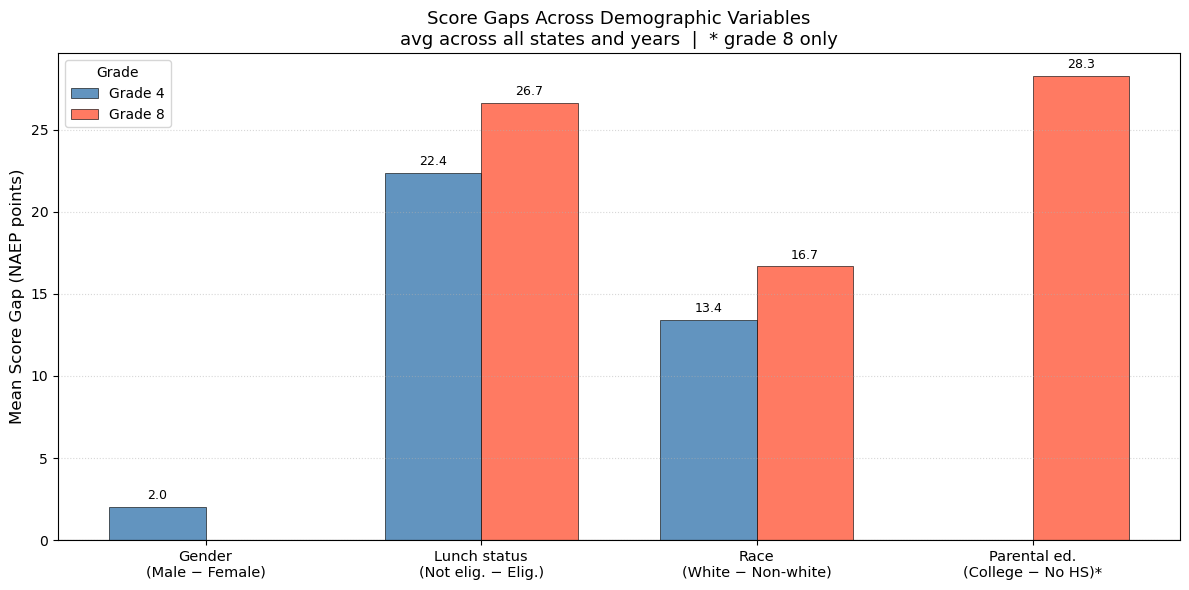

In [47]:
# Print PARED and race column names to confirm what the pivot produced.
# The NAEP category labels get lowercased and space-replaced during pivoting,
# so "Graduated college" becomes "pared_graduated_college" — useful to verify.
pared_cols = sorted([c for c in merged.columns if c.startswith('pared_')])
srace_cols  = sorted([c for c in merged.columns if c.startswith('srace10_')])
print("PARED columns:", pared_cols)
print("SRACE10 columns:", srace_cols)

# Partial keyword search so the code doesn't break if NAEP slightly changes a category label.
def find_col(df, *keywords):
    for kw in keywords:
        matches = [c for c in df.columns if kw.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

# Each tuple holds: display label, advantaged column, disadvantaged column, and which grades to include.
# grades=None means both 4 and 8; grades=[8] restricts to grade 8 only.
GAP_PAIRS = []

if 'gender_male' in merged.columns and 'gender_female' in merged.columns:
    GAP_PAIRS.append(('Gender\n(Male − Female)',
                      'gender_male', 'gender_female', None))

lunch_adv = find_col(merged, 'slunch3_not')
lunch_dis = find_col(merged, 'slunch3_elig')
if lunch_adv and lunch_dis:
    GAP_PAIRS.append(('Lunch status\n(Not elig. − Elig.)',
                      lunch_adv, lunch_dis, None))

# Compare White students to the average of all non-white subgroups.
# Note: Asian/Pacific Islander students score above White students nationally on NAEP math,
# so this composite slightly understates the gap relative to a White vs. Black or
# White vs. Hispanic comparison. Treated here as a known limitation.
race_white    = find_col(merged, 'srace10_white')
nonwhite_cols = [c for c in merged.columns
                 if c.startswith('srace10_') and 'white' not in c.lower()]
if race_white and nonwhite_cols:
    merged['srace10_nonwhite_avg'] = merged[nonwhite_cols].mean(axis=1)
    GAP_PAIRS.append(('Race\n(White − Non-white)',
                      race_white, 'srace10_nonwhite_avg', None))
    print(f"Non-white average from: {nonwhite_cols}")

# PARED is grade 8 only — 4th graders don't report parental education.
pared_high = find_col(merged, 'pared_graduated_college', 'pared_college')
pared_low  = find_col(merged, 'pared_did_not', 'pared_no_hs', 'pared_not_finish')
if pared_high and pared_low:
    GAP_PAIRS.append(('Parental ed.\n(College − No HS)*',
                      pared_high, pared_low, [8]))
    print(f"\nPARED gap: {pared_high} − {pared_low}  (grade 8 only)")
else:
    print("\nPARED columns not matched — available:", pared_cols)

records = []
for label, adv, dis, grades in GAP_PAIRS:
    for grade in ([4, 8] if grades is None else grades):
        sub = merged[merged['grade'] == grade]
        gap = (sub[adv] - sub[dis]).mean()
        records.append({'variable': label, 'grade': grade, 'gap': gap})

gap_summary = pd.DataFrame(records)

variables = [p[0] for p in GAP_PAIRS]
x         = np.arange(len(variables))
bar_width = 0.35
colors    = {4: 'steelblue', 8: 'tomato'}

fig, ax = plt.subplots(figsize=(12, 6))

for i, grade in enumerate([4, 8]):
    vals = []
    for v in variables:
        row = gap_summary[(gap_summary['variable'] == v) & (gap_summary['grade'] == grade)]
        vals.append(row['gap'].values[0] if len(row) else np.nan)

    if all(np.isnan(v) for v in vals):
        continue

    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=f'Grade {grade}', color=colors[grade], alpha=0.85,
                  edgecolor='k', linewidth=0.5)

    for bar, val in zip(bars, vals):
        if not np.isnan(val) and val > 0.5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(variables, fontsize=10.5)
ax.set_ylabel('Mean Score Gap (NAEP points)', fontsize=12)
ax.set_title('Score Gaps Across Demographic Variables\n'
             'avg across all states and years  |  * grade 8 only', fontsize=13)
ax.legend(title='Grade', fontsize=10)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Figure 2 — State Wealth vs. Free-Lunch Score Gap

Scatter of median household income vs. the average NAEP score gap between non-eligible and eligible free-lunch students. Built with `sns.regplot` — the shaded band is a 95% confidence interval around the regression line.

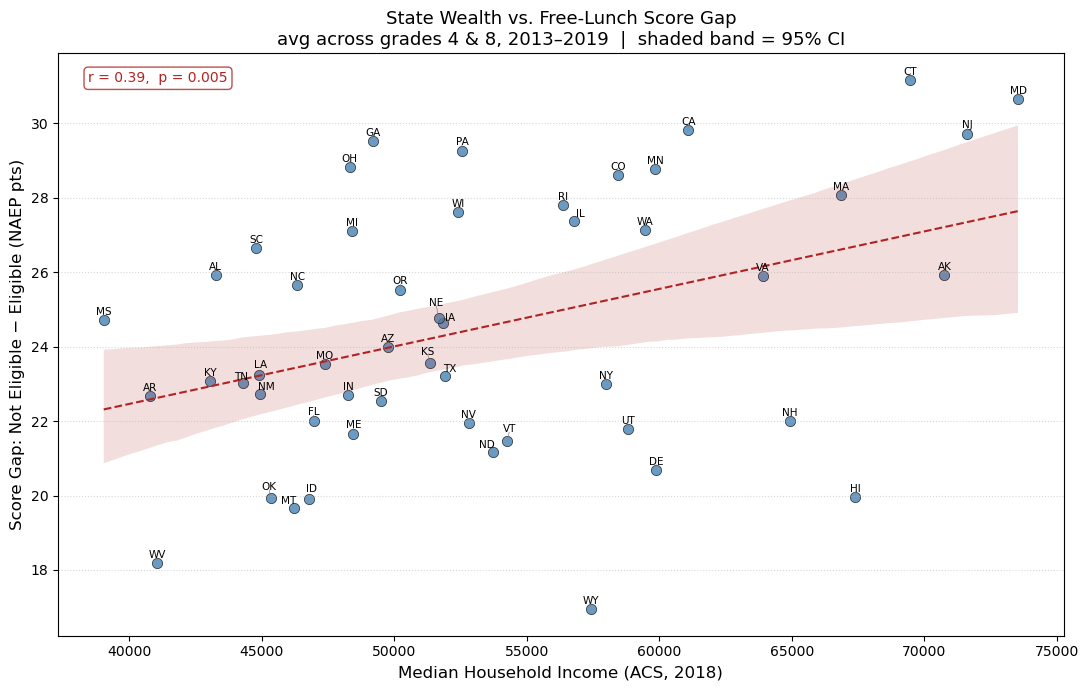

In [48]:
gap_df = merged.copy()
gap_df['score_gap'] = gap_df['slunch3_not_eligible'] - gap_df['slunch3_eligible']

# Collapse to one row per state by averaging the gap across all grade/year combos.
# .first() on median_income just picks the first non-null value — it's the same
# for every row since ACS is a single snapshot.
state_avg = (
    gap_df.groupby('state_abbrev')
    .agg(score_gap=('score_gap', 'mean'),
         median_income=('median_household_income', 'first'))
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 7))

# sns.regplot draws the scatter, fits a linear regression, and shades a 95% CI band —
# all in one call. The CI band is wider at the extremes of income because there are
# fewer states there, so the model is less certain about the true relationship.
sns.regplot(
    data=state_avg,
    x='median_income', y='score_gap',
    ax=ax,
    ci=95,
    scatter_kws=dict(s=55, alpha=0.8, edgecolors='k', linewidths=0.5, color='steelblue'),
    line_kws=dict(color='firebrick', linewidth=1.5, linestyle='--')
)

# adjust_text() nudges labels iteratively until none overlap each other or the data points.
texts = []
for _, row in state_avg.iterrows():
    t = ax.text(row['median_income'], row['score_gap'], row['state_abbrev'],
                fontsize=7.5, ha='center', va='bottom')
    texts.append(t)

adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            expand_points=(1.3, 1.4))

# Pearson r measures the strength and direction of the linear relationship (-1 to 1).
# The p-value tests whether the correlation is statistically distinguishable from zero.
r, p = stats.pearsonr(state_avg['median_income'], state_avg['score_gap'])
p_str = f"p = {p:.3f}" if p >= 0.001 else "p < 0.001"
ax.annotate(f"r = {r:.2f},  {p_str}", xy=(0.03, 0.95), xycoords='axes fraction',
            fontsize=10, color='firebrick',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='firebrick', alpha=0.8))

ax.set_xlabel('Median Household Income (ACS, 2018)', fontsize=12)
ax.set_ylabel('Score Gap: Not Eligible − Eligible (NAEP pts)', fontsize=12)
ax.set_title('State Wealth vs. Free-Lunch Score Gap\n'
             'avg across grades 4 & 8, 2013–2019  |  shaded band = 95% CI', fontsize=13)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 3 — Gender Math Gap Over Time

Average male − female NAEP math score by year, with separate lines for grade 4 and grade 8. This is the starting point for the gender analysis — showing the *size* of the gap directly across years.

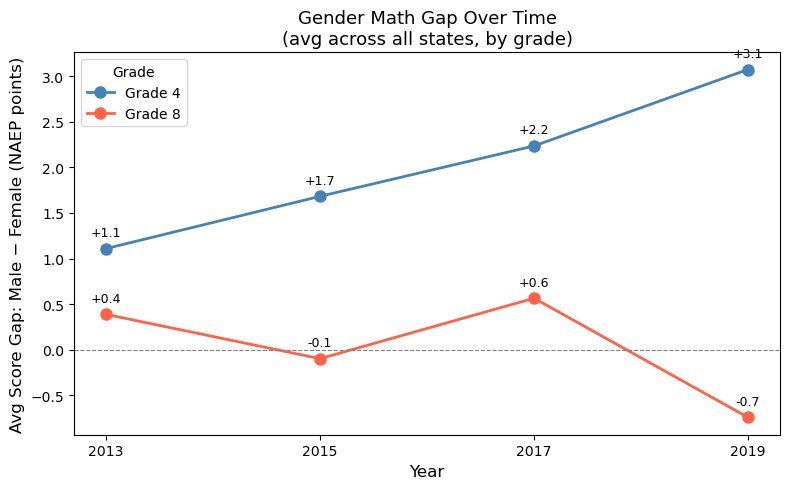

In [49]:
# Compute average male minus female score for each year and grade combination,
# averaged across all states. This gives the national-level gap trajectory.
gender_gap_df = (
    merged.assign(gender_gap=merged['gender_male'] - merged['gender_female'])
          .groupby(['year', 'grade'])['gender_gap']
          .mean()
          .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for grade, color in [(4, 'steelblue'), (8, 'tomato')]:
    sub = gender_gap_df[gender_gap_df['grade'] == grade]
    ax.plot(sub['year'], sub['gender_gap'],
            marker='o', linewidth=2, markersize=8,
            label='Grade ' + str(grade), color=color)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['gender_gap']:+.1f}",
                    (row['year'], row['gender_gap']),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=9)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks([2013, 2015, 2017, 2019])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Score Gap: Male − Female (NAEP points)', fontsize=12)
ax.set_title('Gender Math Gap Over Time\n(avg across all states, by grade)', fontsize=13)
ax.legend(title='Grade', loc='best')
plt.tight_layout()
plt.show()

## Figure 4 — Male vs. Female Score Trajectories Over Time

Instead of just the gap, this shows the actual male and female score trajectories separately — 4 lines total, each with a linear trend line. Shows whether male scores are falling, female scores are rising, or both.

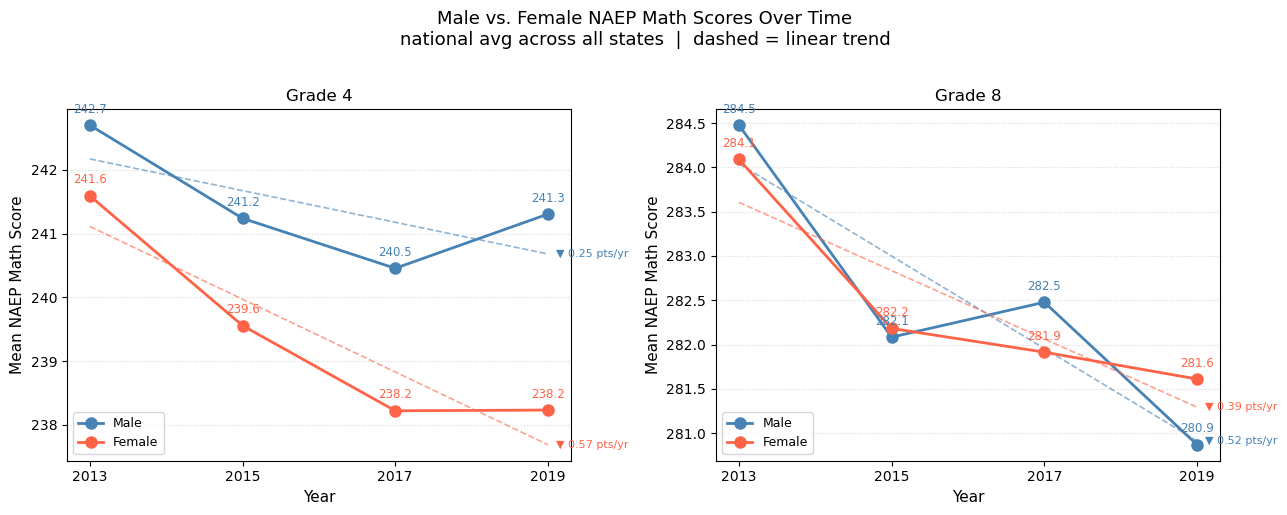

In [50]:
gender_df = (
    merged.groupby(['year', 'grade'])
    .agg(male=('gender_male', 'mean'),
         female=('gender_female', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
YEARS = sorted(gender_df['year'].unique())

for ax, grade in zip(axes, [4, 8]):
    sub = gender_df[gender_df['grade'] == grade].sort_values('year')
    x = sub['year'].values

    for series, color, label in [
        ('male',   'steelblue', 'Male'),
        ('female', 'tomato',    'Female'),
    ]:
        y = sub[series].values

        ax.plot(x, y, marker='o', linewidth=2, markersize=8,
                color=color, label=label)

        for xi, yi in zip(x, y):
            ax.annotate(f"{yi:.1f}", (xi, yi),
                        textcoords='offset points', xytext=(0, 9),
                        ha='center', fontsize=8.5, color=color)

        # stats.linregress fits a simple linear regression and returns the slope.
        # The slope here is in units of NAEP points per year — negative means declining.
        slope, intercept, *_ = stats.linregress(x, y)
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, color=color, linewidth=1.2,
                linestyle='--', alpha=0.6)

        direction = '▲' if slope > 0 else '▼'
        ax.annotate(f"{direction} {abs(slope):.2f} pts/yr",
                    xy=(x[-1], trend_y[-1]),
                    xytext=(6, 0), textcoords='offset points',
                    fontsize=8, color=color, va='center')

    ax.set_xticks(YEARS)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Mean NAEP Math Score', fontsize=11)
    ax.set_title(f'Grade {grade}', fontsize=12)
    ax.legend(loc='lower left', fontsize=9)
    ax.yaxis.grid(True, linestyle=':', alpha=0.5)

fig.suptitle('Male vs. Female NAEP Math Scores Over Time\n'
             'national avg across all states  |  dashed = linear trend',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 5 — OLS Regression: Which Socioeconomic Variables Predict NAEP Scores?

A multivariate OLS regression predicting state mean NAEP scores from ACS socioeconomic variables, visualized as a coefficient plot with 95% CIs. Standardized betas are directly comparable — directly answers which dimension of poverty matters most.

Regression sample: 200 state-year observations
                            OLS Regression Results                            
Dep. Variable:             mean_score   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     43.77
Date:                Tue, 26 May 2026   Prob (F-statistic):           4.41e-30
Time:                        15:38:47   Log-Likelihood:                -207.77
No. Observations:                 200   AIC:                             427.5
Df Residuals:                     194   BIC:                             447.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

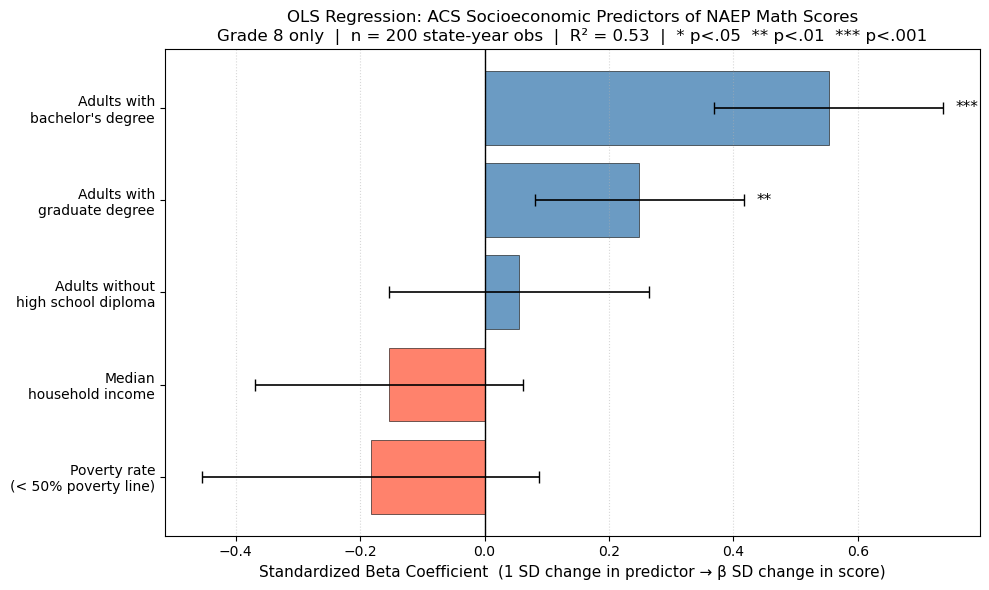


Standardized beta coefficients:
                              label      beta         pval
 Poverty rate\n(< 50% poverty line) -0.182892 1.849502e-01
           Median\nhousehold income -0.153259 1.611295e-01
Adults without\nhigh school diploma  0.055170 6.037113e-01
       Adults with\ngraduate degree  0.248728 3.880231e-03
     Adults with\nbachelor's degree  0.552779 1.334114e-08

Largest predictor: Adults with bachelor's degree (β = 0.553)
  Adults with bachelor's degree is 3.0x stronger than Poverty rate (< 50% poverty line)
  Adults with bachelor's degree is 3.6x stronger than Median household income
  Adults with bachelor's degree is 10.0x stronger than Adults without high school diploma
  Adults with bachelor's degree is 2.2x stronger than Adults with graduate degree


In [51]:
# Restrict to grade 8 — PARED is available here, and the socioeconomic signal tends
# to be stronger at grade 8 since more variance has accumulated by that point.
score_cols = [c for c in merged.columns if any(c.startswith(p) for p in
              ['gender_', 'slunch3_', 'srace10_', 'schtype_'])]

reg_df = merged[merged['grade'] == 8].copy()
reg_df['mean_score'] = reg_df[score_cols].mean(axis=1)

PREDICTORS = [
    'median_household_income',
    'pov_ratio_under_50',
    'educ_less_than_hs',
    'educ_bachelors',
    'educ_graduate',
]
PREDICTORS = [p for p in PREDICTORS if p in reg_df.columns]

# Force everything to float — pd.NA values introduced during the pivot can leave
# columns as object dtype, which statsmodels can't handle.
reg_clean = reg_df[['mean_score'] + PREDICTORS].apply(pd.to_numeric, errors='coerce').dropna()
print(f"Regression sample: {len(reg_clean)} state-year observations")

# Standardize to z-scores so all predictors are on the same scale.
# A beta of 0.5 then means: a one standard deviation increase in that predictor
# is associated with a 0.5 SD increase in NAEP scores, holding others constant.
# Without standardizing, comparing the income coefficient (in dollars) to the
# poverty rate coefficient (in percentage points) would be meaningless.
reg_std = (reg_clean - reg_clean.mean()) / reg_clean.std()

# sm.add_constant() appends a column of 1s, which gives OLS an intercept term to fit.
# Without it, the regression line would be forced through the origin.
X = sm.add_constant(reg_std[PREDICTORS])
y = reg_std['mean_score']

model = sm.OLS(y, X).fit()
print(model.summary())

coef_df = pd.DataFrame({
    'predictor': PREDICTORS,
    'beta':      model.params[PREDICTORS].values,
    'ci_low':    model.conf_int().loc[PREDICTORS, 0].values,
    'ci_high':   model.conf_int().loc[PREDICTORS, 1].values,
    'pval':      model.pvalues[PREDICTORS].values,
})

LABELS = {
    'median_household_income': 'Median\nhousehold income',
    'pov_ratio_under_50':      'Poverty rate\n(< 50% poverty line)',
    'educ_less_than_hs':       'Adults without\nhigh school diploma',
    'educ_bachelors':          "Adults with\nbachelor's degree",
    'educ_graduate':           'Adults with\ngraduate degree',
}
coef_df['label'] = coef_df['predictor'].map(LABELS)
coef_df = coef_df.sort_values('beta')

fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = ['steelblue' if b > 0 else 'tomato' for b in coef_df['beta']]
ax.barh(coef_df['label'], coef_df['beta'],
        color=colors_bar, alpha=0.8, edgecolor='k', linewidth=0.5)

# Error bars show the 95% CI for each coefficient.
# Any bar whose CI crosses zero is not statistically significant at p < 0.05.
ax.errorbar(coef_df['beta'], coef_df['label'],
            xerr=[coef_df['beta'] - coef_df['ci_low'],
                  coef_df['ci_high'] - coef_df['beta']],
            fmt='none', color='black', capsize=4, linewidth=1.2)

for _, row in coef_df.iterrows():
    sig = '***' if row['pval'] < 0.001 else ('**' if row['pval'] < 0.01
          else ('*' if row['pval'] < 0.05 else ''))
    ax.text(row['ci_high'] + 0.02, row['label'], sig, va='center', fontsize=11)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Standardized Beta Coefficient  (1 SD change in predictor → β SD change in score)',
              fontsize=11)
ax.set_title('OLS Regression: ACS Socioeconomic Predictors of NAEP Math Scores\n'
             f'Grade 8 only  |  n = {len(reg_clean)} state-year obs  |  R² = {model.rsquared:.2f}  '
             '|  * p<.05  ** p<.01  *** p<.001',
             fontsize=12)
ax.xaxis.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nStandardized beta coefficients:")
print(coef_df[['label', 'beta', 'pval']].to_string(index=False))
largest = coef_df.iloc[-1]
print(f"\nLargest predictor: {largest['label'].replace(chr(10), ' ')} (β = {largest['beta']:.3f})")
for _, row in coef_df.iterrows():
    if row['predictor'] != largest['predictor'] and row['beta'] != 0:
        ratio = abs(largest['beta'] / row['beta'])
        print(f"  {largest['label'].replace(chr(10),' ')} is {ratio:.1f}x stronger than {row['label'].replace(chr(10),' ')}")